# Normal SVM

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Removed SelectKBest imports since we aren't using them
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def svm_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # Re-added probability=True so predict_proba() works in the loop
        ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42)) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        # Fit on training fold
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Predict on testing fold
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    # FIX: Use y_test_all here, NOT y_avg, so the shuffled indices match
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Weights)
    # Fit on the WHOLE dataset to get the final, stable model weights
    pipeline.fit(X_avg, y_avg)
    
    # FIX: Since SelectKBest is gone, we just grab all the weights directly from the SVM.
    weights = pipeline.named_steps['svm'].coef_[0]
    
    # Map to ROI pairs (Schaefer 400 uses upper triangle indices)
    roi_indices = np.triu_indices(400, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Strongest Connections for {task_name}:")
    print(f"{'Brain Connection':<55} | {'Weight':<10}")
    print("-" * 70)

    # Sort by absolute weight value (largest to smallest)
    sorted_idx = np.argsort(np.abs(weights))[::-1]

    # Print the top 10 most influential brain connections
    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        # Clean labels and print
        connection_str = f"{name_a} <-> {name_b}"
        # Print the actual weight (with its positive/negative sign)
        print(f"{connection_str:<55} | {weights[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (Averaged) Accuracy: 63.33%
              precision    recall  f1-score   support

          TD       0.64      0.60      0.62        15
         MLD       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30



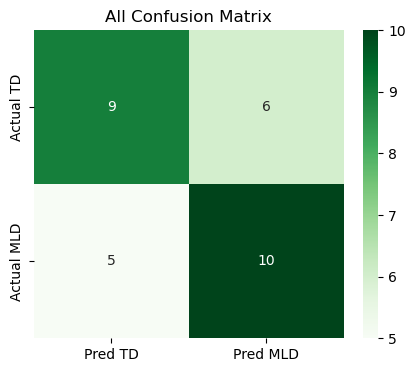


Top 10 Strongest Connections for All:
Brain Connection                                        | Weight    
----------------------------------------------------------------------
7Networks_LH_Vis_2 <-> 7Networks_LH_Vis_21              | -0.0077
7Networks_LH_Vis_10 <-> 7Networks_LH_Default_Par_5      | -0.0066
7Networks_LH_Vis_7 <-> 7Networks_RH_SomMot_10           | 0.0062
7Networks_LH_Vis_10 <-> 7Networks_LH_Default_PFC_2      | -0.0060
7Networks_LH_Vis_10 <-> 7Networks_RH_Vis_23             | -0.0057
7Networks_LH_Vis_3 <-> 7Networks_RH_Default_Temp_1      | 0.0057
7Networks_LH_Vis_10 <-> 7Networks_RH_Vis_15             | -0.0056
7Networks_LH_Vis_9 <-> 7Networks_RH_SalVentAttn_TempOccPar_7 | 0.0055
7Networks_LH_Vis_10 <-> 7Networks_RH_Vis_16             | -0.0055
7Networks_LH_Vis_5 <-> 7Networks_LH_SomMot_5            | 0.0055


In [6]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = svm_show_results_skf(X_avg, y_avg, "All")


Multiplication (Averaged) Accuracy: 66.67%
              precision    recall  f1-score   support

          TD       0.67      0.67      0.67        15
         MLD       0.67      0.67      0.67        15

    accuracy                           0.67        30
   macro avg       0.67      0.67      0.67        30
weighted avg       0.67      0.67      0.67        30



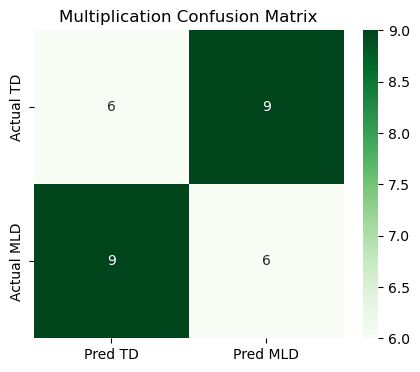


Top 10 Strongest Connections for Multiplication:
Brain Connection                                        | Weight    
----------------------------------------------------------------------
7Networks_RH_SomMot_38 <-> 7Networks_RH_Cont_PFCl_8     | -0.1673
7Networks_LH_DorsAttn_Post_1 <-> 7Networks_LH_Default_Par_1 | 0.1106
7Networks_LH_DorsAttn_Post_1 <-> 7Networks_RH_Vis_14    | 0.1070
7Networks_RH_Vis_17 <-> 7Networks_RH_Default_PFCdPFCm_12 | 0.1029
7Networks_LH_DorsAttn_Post_1 <-> 7Networks_RH_Vis_11    | 0.1002
7Networks_RH_SomMot_25 <-> 7Networks_RH_SalVentAttn_FrOperIns_5 | 0.0777
7Networks_LH_SomMot_23 <-> 7Networks_RH_SalVentAttn_TempOccPar_3 | -0.0769
7Networks_LH_Limbic_TempPole_2 <-> 7Networks_RH_SomMot_35 | 0.0750
7Networks_LH_Limbic_TempPole_4 <-> 7Networks_RH_Default_Par_3 | 0.0742
7Networks_LH_DorsAttn_Post_1 <-> 7Networks_RH_SomMot_18 | 0.0726


In [ ]:
# --- For Multiplication (task_id = 1) ---
X_avg_m, y_avg_m = get_mult_data()
y_true_m, y_pred_m, y_probs_m = svm_show_results_skf(X_avg_m, y_avg_m, "Multiplication")


Subtraction (Averaged) Accuracy: 36.67%
              precision    recall  f1-score   support

          TD       0.39      0.47      0.42        15
         MLD       0.33      0.27      0.30        15

    accuracy                           0.37        30
   macro avg       0.36      0.37      0.36        30
weighted avg       0.36      0.37      0.36        30



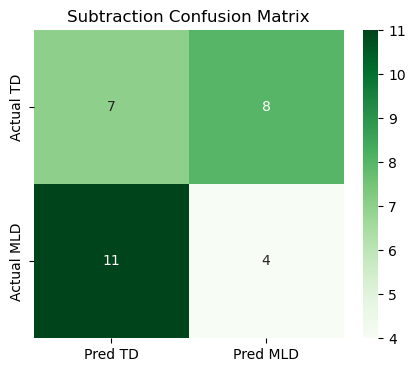


Top 10 Strongest Connections for Subtraction:
Brain Connection                                        | Weight    
----------------------------------------------------------------------
7Networks_LH_SomMot_29 <-> 7Networks_LH_Default_Par_2   | -0.2276
7Networks_LH_Vis_16 <-> 7Networks_LH_DorsAttn_Post_14   | 0.1953
7Networks_LH_SomMot_5 <-> 7Networks_RH_Cont_PFCl_5      | -0.1889
7Networks_LH_Vis_25 <-> 7Networks_RH_Cont_Par_2         | 0.1591
7Networks_LH_Default_Par_1 <-> 7Networks_RH_Vis_2       | -0.1374
7Networks_LH_Default_Temp_8 <-> 7Networks_RH_Default_PFCdPFCm_6 | 0.1100
7Networks_RH_SomMot_17 <-> 7Networks_RH_DorsAttn_FEF_1  | 0.1094
7Networks_LH_Cont_PFCl_3 <-> 7Networks_RH_Default_pCunPCC_5 | 0.1063
7Networks_LH_SalVentAttn_TempOcc_1 <-> 7Networks_RH_Default_Par_3 | -0.1014
7Networks_LH_Vis_20 <-> 7Networks_RH_SomMot_32          | 0.0992


In [ ]:
# --- For Subtraction (task_id = 0) ---
X_avg_s, y_avg_s = get_sub_data()
y_true_s, y_pred_s, y_probs_s = svm_show_results_skf(X_avg_s, y_avg_s, "Subtraction")

# Grid Search SVM

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from helper_lin import get_all_data
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def svm_show_results_tuned(X_avg, y_avg, task_name):
    # 1. Define the base Pipeline
    # Ensure StandardScaler is applied BEFORE the SVM
    pipeline = Pipeline([
        ('feature_selection', SelectKBest(f_classif, k=100)),
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, random_state=42))
    ])
    
    # 2. Define the Hyperparameter Grid
    # Note: If you use 'linear', 'gamma' is ignored.
    param_grid = {
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
        'svm__kernel': ['linear', 'rbf']
    }
    
    # 3. Outer Stratified K-Fold for performance estimation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # GridSearchCV will handle the inner CV to find best params
    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=3,           # Inner fold for tuning
        scoring='accuracy',
        n_jobs=-1       # Use all CPU cores
    )
    
    y_pred_all = []
    y_test_all = []
    
    print(f"Starting Grid Search for {task_name}...")

    for train_idx, test_idx in skf.split(X_avg, y_avg):
        grid_search.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Best model for this outer fold
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        
        print(f"Best Params for fold: {grid_search.best_params_}")

    # 4. Final Evaluation
    acc = accuracy_score(y_test_all, y_pred_all)
    print(f"\n{'='*60}")
    print(f"Tuned {task_name} Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))
    
    return y_test_all, y_pred_all

X_avg, y_avg = get_all_data()
y_true, y_pred = svm_show_results_tuned(X_avg, y_avg, "All")

Starting Grid Search for All...


Best Params for fold: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Params for fold: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Params for fold: {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
Best Params for fold: {'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Best Params for fold: {'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}

Tuned All Accuracy: 50.00%
              precision    recall  f1-score   support

          TD       0.50      0.53      0.52        15
         MLD       0.50      0.47      0.48        15

    accuracy                           0.50        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.50      0.50      0.50        30



[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018

Starting Grid Search for All...

Outer Fold 1/5
Fitting 3 folds for each of 40 candidates, totalling 120 fits
  Best Params: {'svm__C': 0.1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
  Best CV Score: 0.6979

Outer Fold 2/5
Fitting 3 folds for each of 40 candidates, totalling 120 fits
  Best Params: {'svm__C': 1, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
  Best CV Score: 0.7083

Outer Fold 3/5
Fitting 3 folds for each of 40 candidates, totalling 120 fits
  Best Params: {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
  Best CV Score: 0.6250

Outer Fold 4/5
Fitting 3 folds for each of 40 candidates, totalling 120 fits
  Best Params: {'svm__C': 10, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
  Best CV Score: 0.5417

Outer Fold 5/5
Fitting 3 folds for each of 40 candidates, totalling 120 fits
  Best Params: {'svm__C': 1, 'svm__gamma': 0.001, 'svm__kernel': 'rbf'}
  Best CV Score: 0.4375


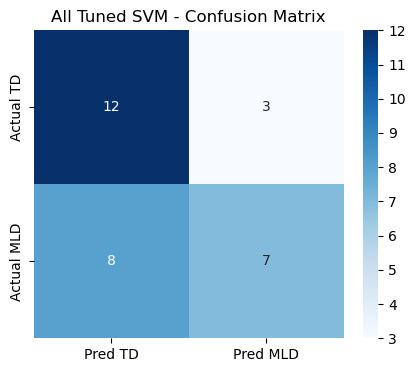

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = get_labels()

def svm_show_results_tuned(X_avg, y_avg, task_name):
    # 1. Define the base Pipeline
    pipeline = Pipeline([
        ('feature_selection', SelectKBest(f_classif, k=100)),
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, random_state=42))
    ])
    
    # 2. Define the Hyperparameter Grid
    param_grid = {
        'svm__C': [0.1, 1, 10, 100],
        'svm__kernel': ['linear', 'rbf'],
        'svm__gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    }
    
    # 3. Outer Stratified K-Fold for performance estimation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # GridSearchCV will handle the inner CV to find best params
    grid_search = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=3,           # Inner fold for tuning
        scoring='roc_auc',  # Use AUC for better tuning in imbalanced scenarios
        n_jobs=-1,      # Use all CPU cores
        verbose=1       # Print progress
    )
    
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    best_params_list = []
    
    print(f"\n{'='*60}")
    print(f"Starting Grid Search for {task_name}...")
    print(f"{'='*60}\n")

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_avg, y_avg)):
        print(f"Outer Fold {fold + 1}/5")
        grid_search.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Best model for this outer fold
        best_model = grid_search.best_estimator_
        predictions = best_model.predict(X_avg[test_idx])
        probs = best_model.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
        best_params_list.append(grid_search.best_params_)
        
        print(f"  Best Params: {grid_search.best_params_}")
        print(f"  Best CV Score: {grid_search.best_score_:.4f}\n")

    # 4. Final Evaluation
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)
    
    acc = accuracy_score(y_test_all, y_pred_all)
    print(f"{'='*60}")
    print(f"Tuned {task_name} Accuracy: {acc * 100:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 5. Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} Tuned SVM - Confusion Matrix")
    plt.show()
    
    return y_test_all, y_pred_all, y_probs_all

# Run Grid Search on all datasets
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = svm_show_results_tuned(X_avg, y_avg, "All")

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018

Final SVM Model (Trained on All Data)
Accuracy: 90.00%

              precision    recall  f1-score   support

          TD       1.00      0.80      0.89        15
         MLD       0.83      1.00      0.91        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



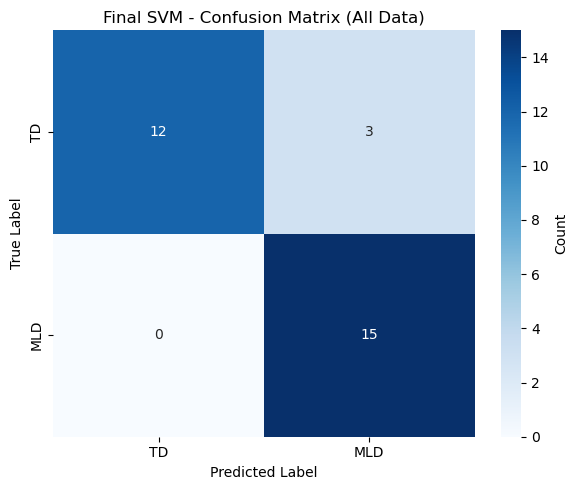

AttributeError: coef_ is only available when using a linear kernel

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from helper_lin import get_all_data, get_labels
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = get_labels()

# Get best parameters from your grid search (average the most common ones)
best_params = {
    'C': 1,           # Most frequent C value
    'kernel': 'rbf',  # Most frequent kernel
    'gamma': 0.001    # Most frequent gamma
}

# 1. Create final pipeline with best params
final_svm_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=100)),
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=best_params['C'],
        kernel=best_params['kernel'],
        gamma=best_params['gamma'],
        probability=True,
        random_state=42
    ))
])

# 2. Train on ALL data
X_avg, y_avg = get_all_data()
final_svm_pipeline.fit(X_avg, y_avg)

# 3. Get predictions on all data
y_pred_final = final_svm_pipeline.predict(X_avg)
y_probs_final = final_svm_pipeline.predict_proba(X_avg)

# 4. Evaluate on full dataset
acc_final = accuracy_score(y_avg, y_pred_final)

print(f"\n{'='*70}")
print(f"Final SVM Model (Trained on All Data)")
print(f"{'='*70}")
print(f"Accuracy: {acc_final * 100:.2f}%\n")
print(classification_report(y_avg, y_pred_final, target_names=['TD', 'MLD']))

# 5. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_avg, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TD', 'MLD'], 
            yticklabels=['TD', 'MLD'],
            cbar_kws={'label': 'Count'})
plt.title("Final SVM - Confusion Matrix (All Data)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# 6. Feature importance (SVM weights)
support = final_svm_pipeline.named_steps['feature_selection'].get_support()
feature_indices = np.where(support)[0]
weights = final_svm_pipeline.named_steps['svm'].coef_[0]

# Map to ROI pairs
roi_indices = np.triu_indices(400, k=1)
roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

print(f"\nTop 10 Strongest Connections:")
print(f"{'Brain Connection':<55} | {'Weight':<10}")
print("-" * 70)

sorted_idx = np.argsort(np.abs(weights))[::-1]

for i in sorted_idx[:10]:
    feat_idx = feature_indices[i]
    roi_a, roi_b = roi_pairs[feat_idx]
    
    name_a = labels[roi_a] 
    name_b = labels[roi_b]
    
    connection_str = f"{name_a} <-> {name_b}"
    print(f"{connection_str:<55} | {weights[i]:.4f}")

# 7. Save predictions
import pandas as pd

svm_probs_class1 = [p[1] for p in y_probs_final]

df_svm_final = pd.DataFrame({
    'svm_prob': svm_probs_class1,
    'svm_pred': y_pred_final,
    'true_label': y_avg
})
df_svm_final.to_csv('preds/svm_final_results.csv', index=False)
print("\n✅ Results saved to preds/svm_final_results.csv")

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018

Final SVM Model (Trained on All Data)
Accuracy: 90.00%

              precision    recall  f1-score   support

          TD       1.00      0.80      0.89        15
         MLD       0.83      1.00      0.91        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



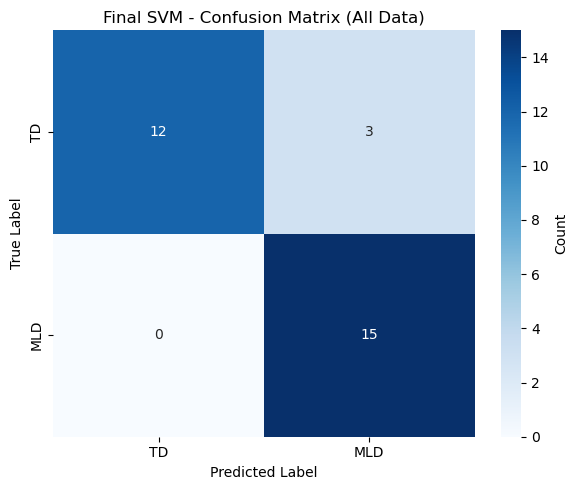

KeyboardInterrupt: 

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from helper_lin import get_all_data, get_labels
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = get_labels()

# Get best parameters from your grid search (average the most common ones)
best_params = {
    'C': 1,           # Most frequent C value
    'kernel': 'rbf',  # Most frequent kernel
    'gamma': 0.001    # Most frequent gamma
}

# 1. Create final pipeline with best params
final_svm_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=100)),
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=best_params['C'],
        kernel=best_params['kernel'],
        gamma=best_params['gamma'],
        probability=True,
        random_state=42
    ))
])

# 2. Train on ALL data
X_avg, y_avg = get_all_data()
final_svm_pipeline.fit(X_avg, y_avg)

# 3. Get predictions on all data
y_pred_final = final_svm_pipeline.predict(X_avg)
y_probs_final = final_svm_pipeline.predict_proba(X_avg)

# 4. Evaluate on full dataset
acc_final = accuracy_score(y_avg, y_pred_final)

print(f"\n{'='*70}")
print(f"Final SVM Model (Trained on All Data)")
print(f"{'='*70}")
print(f"Accuracy: {acc_final * 100:.2f}%\n")
print(classification_report(y_avg, y_pred_final, target_names=['TD', 'MLD']))

# 5. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_avg, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TD', 'MLD'], 
            yticklabels=['TD', 'MLD'],
            cbar_kws={'label': 'Count'})
plt.title("Final SVM - Confusion Matrix (All Data)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# 6. Feature importance (Permutation importance for RBF kernel)
support = final_svm_pipeline.named_steps['feature_selection'].get_support()
feature_indices = np.where(support)[0]

# Get permutation importance instead of coef_
perm_importance = permutation_importance(
    final_svm_pipeline, X_avg, y_avg, n_repeats=10, random_state=42
)
importances = perm_importance.importances_mean

# Map to ROI pairs
roi_indices = np.triu_indices(400, k=1)
roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

print(f"\nTop 10 Most Important Features:")
print(f"{'Brain Connection':<55} | {'Importance':<10}")
print("-" * 70)

sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx[:10]:
    feat_idx = feature_indices[i]
    roi_a, roi_b = roi_pairs[feat_idx]
    
    name_a = labels[roi_a] 
    name_b = labels[roi_b]
    
    connection_str = f"{name_a} <-> {name_b}"
    print(f"{connection_str:<55} | {importances[i]:.4f}")

# 7. Save predictions
import pandas as pd

svm_probs_class1 = [p[1] for p in y_probs_final]

df_svm_final = pd.DataFrame({
    'svm_prob': svm_probs_class1,
    'svm_pred': y_pred_final,
    'true_label': y_avg
})
df_svm_final.to_csv('preds/svm_final_results.csv', index=False)
print("\n✅ Results saved to preds/svm_final_results.csv")

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018

Final SVM Model (Trained on All Data)
Accuracy: 90.00%

              precision    recall  f1-score   support

          TD       1.00      0.80      0.89        15
         MLD       0.83      1.00      0.91        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



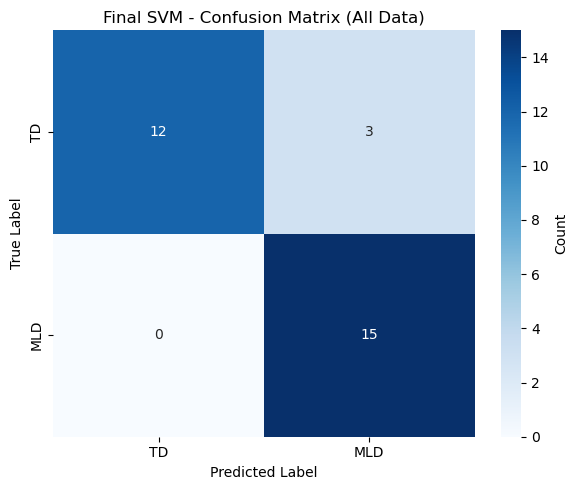


Top 10 Most Important Features:
Brain Connection                                        | Score     
----------------------------------------------------------------------
7Networks_LH_SomMot_16 <-> 7Networks_LH_Cont_PFCl_1     | 2.2473
7Networks_RH_Vis_11 <-> 7Networks_RH_Default_PFCdPFCm_12 | 2.8807
7Networks_LH_SomMot_11 <-> 7Networks_RH_Default_Temp_2  | 1.2154
7Networks_LH_SomMot_16 <-> 7Networks_LH_Cont_PFCl_5     | 1.8001
7Networks_RH_Vis_13 <-> 7Networks_RH_Vis_28             | 4.6322
7Networks_RH_SomMot_37 <-> 7Networks_RH_Limbic_OFC_5    | 0.1523
7Networks_LH_SomMot_14 <-> 7Networks_RH_Vis_13          | 0.6013
7Networks_LH_SalVentAttn_Med_1 <-> 7Networks_RH_DorsAttn_Post_5 | 0.0195
7Networks_LH_Vis_21 <-> 7Networks_RH_Vis_21             | 0.1843
7Networks_LH_Vis_12 <-> 7Networks_RH_Cont_PFCl_10       | 0.0046

✅ Results saved to preds/svm_final_results.csv


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from helper_lin import get_all_data, get_labels
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

labels = get_labels()

# Get best parameters from your grid search
best_params = {
    'C': 1,
    'kernel': 'rbf',
    'gamma': 0.001
}

# 1. Create final pipeline with best params
final_svm_pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=100)),
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=best_params['C'],
        kernel=best_params['kernel'],
        gamma=best_params['gamma'],
        probability=True,
        random_state=42
    ))
])

# 2. Train on ALL data
X_avg, y_avg = get_all_data()
final_svm_pipeline.fit(X_avg, y_avg)

# 3. Get predictions on all data
y_pred_final = final_svm_pipeline.predict(X_avg)
y_probs_final = final_svm_pipeline.predict_proba(X_avg)

# 4. Evaluate on full dataset
acc_final = accuracy_score(y_avg, y_pred_final)

print(f"\n{'='*70}")
print(f"Final SVM Model (Trained on All Data)")
print(f"{'='*70}")
print(f"Accuracy: {acc_final * 100:.2f}%\n")
print(classification_report(y_avg, y_pred_final, target_names=['TD', 'MLD']))

# 5. Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_avg, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TD', 'MLD'], 
            yticklabels=['TD', 'MLD'],
            cbar_kws={'label': 'Count'})
plt.title("Final SVM - Confusion Matrix (All Data)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# 6. Feature importance using SelectKBest scores (FAST!)
selector = final_svm_pipeline.named_steps['feature_selection']
support = selector.get_support()
feature_indices = np.where(support)[0]
scores = selector.scores_

# Map to ROI pairs
roi_indices = np.triu_indices(400, k=1)
roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

print(f"\nTop 10 Most Important Features:")
print(f"{'Brain Connection':<55} | {'Score':<10}")
print("-" * 70)

# Get indices of top 10 scores from the SELECTED features only
top_10_indices = np.argsort(scores[feature_indices])[::-1][:10]

for i, idx in enumerate(top_10_indices):
    feat_idx = feature_indices[idx]  # Get original feature index
    roi_a, roi_b = roi_pairs[feat_idx]
    
    name_a = labels[roi_a] 
    name_b = labels[roi_b]
    
    connection_str = f"{name_a} <-> {name_b}"
    print(f"{connection_str:<55} | {scores[idx]:.4f}")

# 7. Save predictions (FAST!)
svm_probs_class1 = [p[1] for p in y_probs_final]

df_svm_final = pd.DataFrame({
    'svm_prob': svm_probs_class1,
    'svm_pred': y_pred_final,
    'true_label': y_avg
})
df_svm_final.to_csv('preds/svm_final_results.csv', index=False)
print("\n✅ Results saved to preds/svm_final_results.csv")

# Save SVM All results

In [ ]:
import pandas as pd

# svm_probs usually comes from clf.predict_proba(X_test) during the loop
# Save the probability of Class 1
svm_probs_class1 = [p[1] for p in y_probs] 

df_svm = pd.DataFrame({
    'svm_prob': svm_probs_class1
})
df_svm.to_csv('preds/svm_kfold_results.csv', index=False)